Loading imports,

In [1]:
import re
import pandas as pd
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

analyzer = SentimentIntensityAnalyzer()
translator = GoogleTranslator(source="auto", target="en")

# Reddit Data (Skip this)

This code loads the raw Reddit dataset from a CSV file, then creates a clean and unified text column by using the translated version when available and falling back to the original text if not. It converts Unix timestamps into readable datetime format, standardizes the columns into a structured format (platform, content type, text, date, engagement, and ID), and ensures each row has a usable identifier. Overall, it transforms messy Reddit data into a clean, structured dataset ready for analysis or merging with other platforms.

In [1]:
df_reddit = pd.read_csv("Redditdata.csv")
df_reddit["text"] = df_reddit["translated_text"].fillna(df_reddit["original_text"])

NameError: name 'pd' is not defined

In [2]:
def translate_to_english(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return text
        return translator.translate(str(text))
    except Exception:
        return text

df_reddit["text_en"] = df_reddit["text"].apply(translate_to_english)

NameError: name 'df_reddit' is not defined

In [3]:
df_reddit_clean = pd.DataFrame({
    "platform": "reddit",
    "content_type": df_reddit["type"],
    "original_text": df_reddit["text"],          # original/unified text
    "translated_text": df_reddit["text_en"],     # English version
    "date": pd.to_datetime(df_reddit["created_utc"], unit="s"),
    "engagement": df_reddit["score"],
    "id": df_reddit["post_id"].fillna(df_reddit["comment_id"])
})

NameError: name 'pd' is not defined

In [4]:
df_reddit_clean.to_csv("RedditWithEnglish.csv", index=False)

NameError: name 'df_reddit_clean' is not defined

# Facebook Data (Skip this)

For `PostsData.csv`, produces a CSV with the English translations since running the cells takes some time.

In [38]:
df_posts = pd.read_csv("PostsData.csv")

df_posts["translated_text"] = df_posts["text"].apply(translate_to_english)

df_posts.to_csv("PostsData_Translated.csv", index=False)

Also produces a CSV with English translations for `CommentsData.csv` since running the cell takes time.

In [39]:
df_comments = pd.read_csv("CommentsData.csv")

df_comments["translated_text"] = df_comments["text"].apply(translate_to_english)

df_comments.to_csv("CommentsData_Translated.csv", index=False)

# Cleaning and Merging Datasets (Start here)

Loading all translated files

In [2]:
df_reddit = pd.read_csv("RedditWithEnglish.csv")
df_posts = pd.read_csv("PostsData_Translated.csv")
df_comments = pd.read_csv("CommentsData_Translated.csv")

Converts the `timestamp` column into numeric format and transforms it into a proper datetime column called `date`. It then calculates total engagement by summing all Facebook reaction counts per post. Finally, it creates a cleaned dataframe (`df_posts_clean`) that standardizes key fields such as platform, content type, text, translated text, date, engagement, and post ID for further analysis.

In [3]:
df_posts["timestamp"] = pd.to_numeric(df_posts["timestamp"], errors="coerce")
df_posts["date"] = pd.to_datetime(df_posts["timestamp"], unit="s", errors="coerce")

df_posts["total_reactions"] = df_posts[
    ["reactionLikeCount","reactionLoveCount","reactionSadCount",
     "reactionAngryCount","reactionWowCount","reactionHahaCount"]
].sum(axis=1)

df_posts_clean = pd.DataFrame({
    "platform": "facebook",
    "content_type": "post",
    "original_text": df_posts["text"],
    "translated_text": df_posts["translated_text"],
    "date": df_posts["date"],
    "engagement": df_posts["total_reactions"],
    "id": df_posts["postId"]
})

Creates a cleaned dataframe called `df_comments_clean` that standardizes Facebook comment data for analysis. It labels the platform and content type, keeps the original and translated text, assigns `None` to the date since no timestamp is available, uses `likesCount` as the engagement metric, and stores the comment ID for reference.

In [4]:
df_comments_clean = pd.DataFrame({
    "platform": "facebook",
    "content_type": "comment",
    "original_text": df_comments["text"],
    "translated_text": df_comments["translated_text"],
    "date": None,  # no timestamp available
    "engagement": df_comments["likesCount"],
    "id": df_comments["commentId"]
})

Merging all the files together

In [5]:
df_master = pd.concat(
    [df_reddit, df_posts_clean, df_comments_clean],
    ignore_index=True
)

df_master = df_master.dropna(subset=["translated_text"])
df_master = df_master[df_master["translated_text"].str.strip() != ""]

In [6]:
print(df_master.shape)

(1068, 7)


### Risk Analysis

This section creates binary indicator columns to flag posts that discuss specific risk-related themes. It uses keyword matching on the `translated_text` column with `str.contains()` and regular expression patterns.

Four topic categories are defined:

- **is_tuition**: Flags posts that mention tuition-related concerns such as tuition, fees, increases, or “dagdag.”
- **is_protest**: Identifies posts discussing protests, rallies, boycotts, strikes, walkouts, unfair treatment, abuse, or related Filipino terms.
- **is_4th_year**: Captures content related to graduating students, including 4th year, thesis, capstone, internship, or OJT.
- **is_pep**: Detects mentions of the PEP employability program, placement, 90 days, or job-related discussions.

The parameters `case=False` and `na=False` ensure that matching is case-insensitive and that missing values do not produce errors. Each resulting column contains `True` or `False`, allowing structured filtering and analysis of these risk categories.

In [7]:
df_master["is_tuition"] = df_master["translated_text"].str.contains(
    r"tuition|fee|bayad|increase|dagdag",
    case=False,
    na=False
)

In [8]:
df_master["is_protest"] = df_master["translated_text"].str.contains(
    r"protest|rally|boycott|strike|walkout|unfair|abuse|hindi makatarungan",
    case=False,
    na=False
)

In [9]:
df_master["is_4th_year"] = df_master["translated_text"].str.contains(
    r"4th year|graduating|thesis|capstone|internship|OJT",
    case=False,
    na=False
)

In [10]:
df_master["is_pep"] = df_master["translated_text"].str.contains(
    r"PEP|placement|90 days|employability|job",
    case=False,
    na=False
)

Just to get a count of the mentions of the keywords from each category:

In [11]:
print("Tuition mentions:", df_master["is_tuition"].sum())
print("Protest mentions:", df_master["is_protest"].sum())
print("4th year mentions:", df_master["is_4th_year"].sum())
print("PEP mentions:", df_master["is_pep"].sum())

Tuition mentions: 87
Protest mentions: 23
4th year mentions: 8
PEP mentions: 18


# Sentiment Analysis

Defines a function that uses VADER to compute the compound sentiment score of a given text. It then applies this function to the `translated_text` column in `df_master` and stores the resulting sentiment scores in a new column called `sentiment_score`.

In [12]:
def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    return scores["compound"]

df_master["sentiment_score"] = df_master["translated_text"].apply(get_sentiment)

Defines a function that converts a numeric VADER compound score into a categorical label. Scores ≥ 0.05 are labeled positive, scores ≤ -0.05 are labeled negative, and values in between are labeled neutral. The function is then applied to the `sentiment_score` column to create a new `sentiment_label` column in `df_master`.

In [13]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df_master["sentiment_label"] = df_master["sentiment_score"].apply(label_sentiment)

Gives the overall sentiment distribution

In [14]:
print(df_master["sentiment_label"].value_counts(normalize=True))

sentiment_label
positive    0.494382
negative    0.282772
neutral     0.222846
Name: proportion, dtype: float64


Sentiment distribution for **tuition-related rows**

In [15]:
tuition_df = df_master[df_master["is_tuition"] == True]
print(tuition_df["sentiment_label"].value_counts(normalize=True))

sentiment_label
positive    0.678161
negative    0.298851
neutral     0.022989
Name: proportion, dtype: float64


Sentiment distribution for **4th year students**

In [16]:
fourth_year_df = df_master[df_master["is_4th_year"] == True]

print(fourth_year_df["sentiment_label"].value_counts(normalize=True))

sentiment_label
positive    0.625
negative    0.375
Name: proportion, dtype: float64


Saving as csv. Uncomment this and run the cell if you still need the file.

In [17]:
# df_master.to_csv("UNC_MasterDataset_WithSentiment.csv", index=False)

# Clustering

This code defines a `clean_text()` function that standardizes text by converting it to lowercase, removing URLs, and stripping out numbers, punctuation, and special characters. It then applies this function to the `translated_text` column and saves the cleaned result in a new column called `clean_text`, preparing the data for further analysis.

In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df_master["clean_text"] = df_master["translated_text"].apply(clean_text)

This code imports the `SentenceTransformer` class and loads a pre-trained model called `"all-MiniLM-L6-v2"`. The model is used to convert text into numerical vector representations (embeddings), which allow the text to be processed for tasks such as clustering, similarity analysis, or other machine learning applications.

In [19]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

c:\Users\Raymond\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1138.97it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


This code uses the loaded SentenceTransformer model to convert the `clean_text` column into numerical vector representations called embeddings. It first turns the column into a list, then applies the model’s `encode()` function to generate embeddings for each text entry. The `show_progress_bar=True` argument displays a progress bar while the encoding process runs.

In [20]:
embeddings = model.encode(
    df_master["clean_text"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 34/34 [00:00<00:00, 68.92it/s]


This code imports the KMeans clustering algorithm and sets the number of clusters to 5. It initializes the model with `random_state=42` to ensure consistent results across runs. The model is then fitted to the text embeddings, and each data point is assigned to one of the five clusters. The resulting cluster labels are stored in a new column called `cluster` in the dataframe.

In [21]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df_master["cluster"] = kmeans.fit_predict(embeddings)

This code groups the dataframe by the `cluster` column and calculates the average `sentiment_score` for each cluster. It helps show the overall sentiment trend within each cluster by summarizing whether the texts in that group are generally positive, negative, or neutral.

In [22]:
df_master.groupby("cluster")["sentiment_score"].mean()

cluster
0    0.124357
1    0.149347
2    0.365845
3    0.108190
4    0.126038
Name: sentiment_score, dtype: float64

# Cluster Interpretations 

## Cluster 0

Code below prints the total rows, average sentiment, and all the texts involved with the cluster.

In [23]:
cluster_0 = df_master[df_master["cluster"] == 0]

print("CLUSTER 0")
print("Total rows:", len(cluster_0))
print("Average sentiment:", cluster_0["sentiment_score"].mean())
print("\nTexts:\n")

for text in cluster_0["translated_text"]:
    print("-", text)

CLUSTER 0
Total rows: 262
Average sentiment: 0.12435687022900765

Texts:

- #GreyhoundFreedomWall6905

(Rant)
Foundation day pero regular class HAHAHAHAHAHAHA
- #GreyhoundFreedomWall6904

(RANT) 
Hello, I just want to ask if you are also connected to wifi? My password doesn't work anymore, it just started when I enrolled, all my classmates can't connect to the wifi, is that right?
- #GreyhoundFreedomWall6903

[QUESTION]

EA!!!!! Sali tayo Chinese Garter!!!
- #GreyhoundFreedomWall6902

(Help)

Hello po! I lost my school ID last family day po. Huhu it has cat keychain, inhaler, and the lower part is gone po. + I’m a shs female student po. If anyone has it po, please surrender it to the security office or comment down below po. Thank you po. 🥲🥲
- #GreyhoundFreedomWall6900

(QUESTION, HELP)

Hi! I lost my top spiral notebook A5 size (the letters are ugly) in the NB or HS building (I don't know which room it's on the 2nd floor). If you ever see it, kindly react to this post. THANKYOUSM!
- #

## Cluster 1

Code below prints the total rows, average sentiment, and all the texts involved with the cluster.

In [24]:
cluster_1 = df_master[df_master["cluster"] == 1]

print("CLUSTER 1")
print("Total rows:", len(cluster_1))
print("Average sentiment:", cluster_1["sentiment_score"].mean())
print("\nTexts:\n")

for text in cluster_1["translated_text"]:
    print("-", text)

CLUSTER 1
Total rows: 192
Average sentiment: 0.1493473958333333

Texts:

- How’s the semester so far? Sobrang daming ganaps lately. How are you coping?
- My family had a great experience studying at UNC, and I also enjoyed my time learning there. It was very affordable and provided quality education during JHS. When Senior High School came, it was a game changer. Our presentation skills, research, and other practical abilities, including (but not limited to) English writing and speaking were honed thoroughly.

UNC has helped shape many leaders and offered students ample opportunities to be empowered. However, it's important to acknowledge that the university is not without its flaws.
- BSN ENVIRONMENT hello, im an upcoming first-year college student and iam taking BSN in UNC because tf is affordable unlike ADNU or USI. Is the profs and environment okay at unc or should I just transfer to USI (cons are expensive tf)
- That's not in school 🤗 just do your best always. 
Been with UNC when 

## Cluster 2

Code below prints the total rows, average sentiment, and all the texts involved with the cluster.

In [25]:
cluster_2 = df_master[df_master["cluster"] == 2]

print("CLUSTER 2")
print("Total rows:", len(cluster_2))
print("Average sentiment:", cluster_2["sentiment_score"].mean())
print("\nTexts:\n")

for text in cluster_2["translated_text"]:
    print("-", text)

CLUSTER 2
Total rows: 176
Average sentiment: 0.3658448863636364

Texts:

- I need a friend I don't know but until now I can't find a circle at school. I also can't figure out if I'm the problem or if I just can't get along with people at school. Even if it's not a circle, even if it's not a group, even if it's just a sensible friend, I'm okay but why do people seem to be fake lately? It's hard to socialize, it's sad.
- #GreyhoundFreedomWall6901

[confession]

sa babae na kumukuha ng id kanina paglabas nung nstp (secret kung alin basta may salamin) i just wanna say na ang ganda mo. even if my id is yours oh
- #GreyhoundFreedomWall6898

rant and mental health
 Hi I'm a student and honestly why do I have to act a whole new different person in my classroom I just hate it when I get fun of by being myself they always hate when Im energetic and loud which I get but calling me as an ADHD or Acoustic person Is just wrong and I've been in this university for 9 years (2017) and I've never experi

## Cluster 3

Code below prints the total rows, average sentiment, and all the texts involved with the cluster.

In [26]:
cluster_3 = df_master[df_master["cluster"] == 3]

print("CLUSTER 3")
print("Total rows:", len(cluster_3))
print("Average sentiment:", cluster_3["sentiment_score"].mean())
print("\nTexts:\n")

for text in cluster_3["translated_text"]:
    print("-", text)

CLUSTER 3
Total rows: 369
Average sentiment: 0.10819024390243903

Texts:

- TOO EXHAUSTED
- Bakit sa UNC? What made you decide to enroll in the University of Nueva Caceres despite having a pool of academic institutions in the Bicol Region?
- hello, planning to transfer sa unc and im an incoming 2nd yr BSN, may nahanap na ba u affordable na bhouse near the uni?
- 2025 The Times Higher Ranking Congratulations to the five Bicol Higher Education Institutions that made it to the Times Higher Education Impact Rankings 2025! 🎉

• Central Bicol State University – Ranked 801–1000

• Sorsogon State University – Ranked 1001–1500

• Bicol University – Ranked 1501+

• Catanduanes State University – Ranked 1501+

• University of Nueva Caceres – Ranked 1501+

Your accomplishments highlight the growing impact and excellence of higher education in the Bicol Region.

-CHED RO V
- How to know my block section? hi! How do I know the block section assigned to me? is it thru portal? thank you
- do you have 

## Cluster 4

Code below prints the total rows, average sentiment, and all the texts involved with the cluster.

In [27]:
cluster_4 = df_master[df_master["cluster"] == 4]

print("CLUSTER 4")
print("Total rows:", len(cluster_4))
print("Average sentiment:", cluster_4["sentiment_score"].mean())
print("\nTexts:\n")

for text in cluster_4["translated_text"]:
    print("-", text)

CLUSTER 4
Total rows: 69
Average sentiment: 0.12603768115942032

Texts:

- jhs high school students, what's so hard to understand that you can't steal when you're wearing uniform in cc during class hours? You don't even take the ball. What a leaky head you are
- Looking for... Hey everyone, I am a freshmen working student, currently I am looking for pre-loved uniform, mahal ng orig eh... huhuhu can’t afford the uniform... kung sino man meron Size M sana
- #GreyhoundFreedomWall6888

[Question, Help]

Hello po! I am selling my two (2) medium uniform blouse (Good as new). price is negotiable naman. 

Kindly comment to this post na lang po for the price and for availing po, thank you!
- #GreyhoundFreedomWall6884

[Question & Help]

hello! i'm selling my Medium size Blouse+Pants (im 5'0 btw)
Also my Chefs Uniform Medium (Good as New)

for interested, kindly react nalang to this post. thank you!
- #GreyhoundFreedomWall6883

(Question)
Hi Po!  Who is the d2 graduating student who is going to 

# Graphs

## Cluster 0

### Ignore this

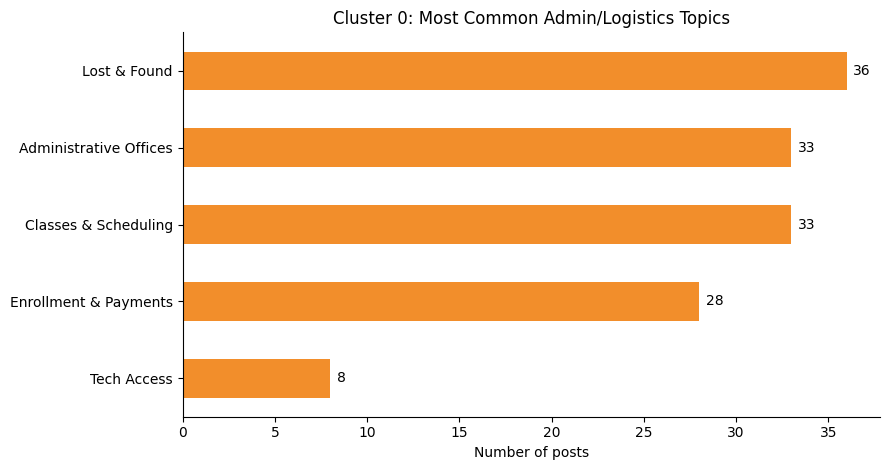

In [28]:
cluster_0 = df_master[df_master["cluster"] == 0].copy()
text_col = "translated_text"  # change if needed

def has_any(text: str, patterns) -> bool:
    if pd.isna(text):
        return False
    t = str(text).lower()
    return any(re.search(p, t) for p in patterns)

# Define subtopics 
# More generalized subtopics (no slashes)
TOPICS = {
    "Enrollment & Payments": [
        r"\benroll", r"\benrollment", r"\boes\b", r"\bportal\b", r"\bstudent portal\b",
        r"\bmatric", r"\bassessment\b", r"\bpayment\b", r"\bpay\b", r"\btuition\b",
        r"\bbalance\b", r"\bpromissory\b", r"\b60%\b", r"\brestriction\b", r"\bclosed\b"
    ],
    "Classes & Scheduling": [
        r"\bgclass\b", r"\bclass code\b", r"\bcode\b", r"\bgc\b", r"\bgroup chat\b",
        r"\bsched\b", r"\bschedule\b", r"\bswap\b", r"\bsection\b", r"\bblock\b",
        r"\broom\b", r"\bclassroom\b"
    ],
    "Tech Access": [
        r"\bwifi\b", r"\binternet\b", r"\bmoodle\b", r"\be-?lib\b", r"\bcanva pro\b",
        r"\bpassword\b", r"\bconnect\b"
    ],
    "Administrative Offices": [
        r"\bregistrar\b", r"\bosa\b", r"\bvpaa\b", r"\bstaff\b", r"\badmin\b",
        r"\boffice\b", r"\bsecurity office\b"
    ],
    "Lost & Found": [
        r"\blost\b", r"\bfound\b", r"\bmissing\b", r"\bwallet\b", r"\bid\b", r"\biphone\b",
        r"\bphone\b", r"\bcharger\b", r"\bearbuds\b", r"\bairpods\b", r"\bnotebook\b",
        r"\bumbrella\b", r"\beglasses\b", r"\bpowerbank\b"
    ],
}

# Build boolean columns
for topic, pats in TOPICS.items():
    cluster_0[topic] = cluster_0[text_col].apply(lambda x: has_any(x, pats))

topic_counts = cluster_0[list(TOPICS.keys())].sum().sort_values()  

fig, ax = plt.subplots(figsize=(9, 4.8))
topic_counts.plot(kind="barh", ax=ax, color="#F28E2B")
ax.set_title("Cluster 0: Most Common Admin/Logistics Topics")
ax.set_xlabel("Number of posts")  # change to "Percent of posts (%)" if using mean()*100
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# value labels
for i, v in enumerate(topic_counts.values):
    ax.text(v + (topic_counts.max() * 0.01), i, f"{int(v)}", va="center")

plt.tight_layout()
plt.show()

### This is the graph I used

In [29]:
cluster_0 = df_master[df_master["cluster"] == 0].copy()
text_col = "translated_text"

def has_any(text, patterns):
    if pd.isna(text):
        return False
    t = str(text).lower()
    return any(re.search(p, t) for p in patterns)

ADMIN_FOCUS = {
    "Enrollment System (OES)": [
        r"\boes\b", r"\bportal\b", r"\bstudent portal\b", r"\benroll", r"\benrollment\b",
        r"\bnot enrolled\b", r"\bmatric", r"\bassessment\b"
    ],
    "Registrar Office": [
        r"\bregistrar\b"
    ],
    "Student affairs": [
        r"\bosa\b", r"\bstudent assistant\b", r"\bdean lister\b"
    ],
    "Security": [
        r"\bsecurity\b", r"\bguard\b"
    ],
}

admin_counts = {}
for k, pats in ADMIN_FOCUS.items():
    admin_counts[k] = cluster_0[text_col].apply(lambda x: has_any(x, pats)).sum()

admin_counts = pd.Series(admin_counts).sort_values(ascending=False)
admin_counts

Enrollment System (OES)    20
Security                   15
Student affairs             5
Registrar Office            2
dtype: int64

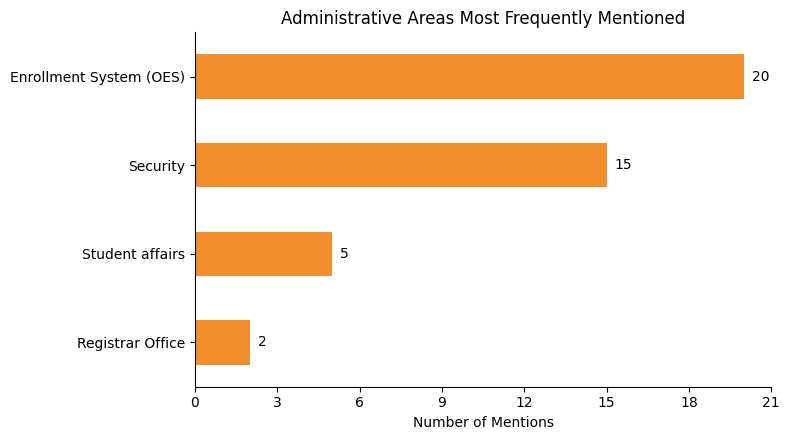

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Sort values
admin_counts = admin_counts.sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
admin_counts.plot(kind="barh", ax=ax, color="#F28E2B")

ax.set_title("Administrative Areas Most Frequently Mentioned")
ax.set_xlabel("Number of Mentions")
ax.set_ylabel("")

# Force whole numbers on x-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value labels
for i, v in enumerate(admin_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

plt.tight_layout()
plt.show()

## Cluster 1

In [31]:
COMPLAINT_FOCUS = {
    "Instructional Quality": [
        r"\bnot teaching\b", r"\bconfusing\b", r"\bunclear\b",
        r"\bdoesn't teach\b", r"\bno teaching\b",
        r"\bnot prepared\b", r"\bpoor explanation\b"
    ],
    "Assessment": [
        r"\bunfair\b", r"\bfavoritism\b", r"\bbacker\b",
        r"\bbias\b", r"\bgrading\b", r"\blow grades\b",
        r"\bhigh standards\b", r"\bfailed\b"
    ],
    "Culture": [
        r"\btoxic\b", r"\bcompetitive\b",
        r"\bbullying\b", r"\bperformative\b",
        r"\bpressure\b"
    ],
    "Pedagogy": [
        r"\bflip classroom\b", r"\bflipped\b",
        r"\bindependent learner\b",
        r"\bstudent-centric\b"
    ]
}

In [32]:
def tag_complaint(text):
    text = str(text).lower()
    
    for category, patterns in COMPLAINT_FOCUS.items():
        for pattern in patterns:
            if re.search(pattern, text):
                return category
    return None

df_master["complaint_category"] = df_master["translated_text"].apply(tag_complaint)

In [33]:
complaints_df = df_master[df_master["complaint_category"].notna()]

In [34]:
complaint_counts = complaints_df["complaint_category"].value_counts()

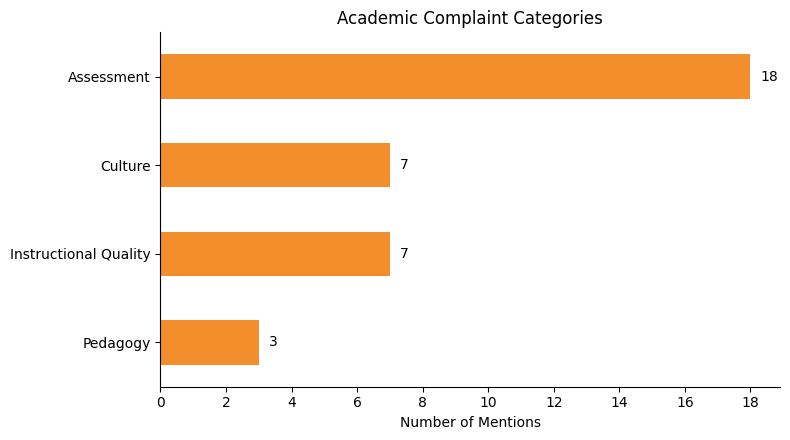

In [35]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Sort values (smallest on top, largest at bottom)
complaint_counts = complaint_counts.sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))

complaint_counts.plot(
    kind="barh",
    ax=ax,
    color="#F28E2B"
)

ax.set_title("Academic Complaint Categories")
ax.set_xlabel("Number of Mentions")
ax.set_ylabel("")

# Force whole numbers on x-axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Remove extra borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels
for i, v in enumerate(complaint_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

plt.tight_layout()
plt.show()

## Cluster 2

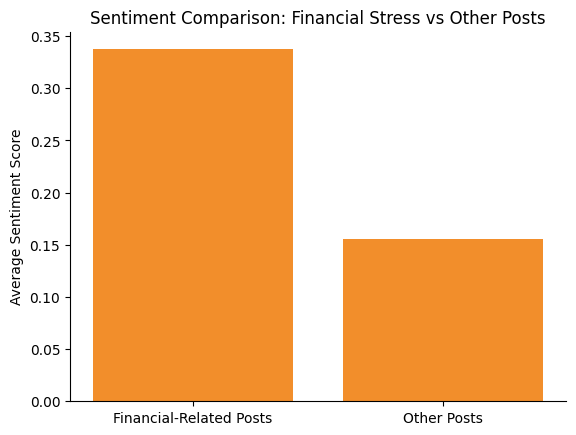

In [36]:
df_master = pd.read_csv("UNC_MasterDataset_WithSentiment.csv")

# If 'cluster' column exists, filter Cluster 2
if "cluster" in df_master.columns:
    cluster_2 = df_master[df_master["cluster"] == 2].copy()
else:
    cluster_2 = df_master.copy()

# Define financial-related keywords
financial_keywords = [
    "tuition", "money", "expensive", "no money", "financial", 
    "therapy", "allowance", "budget", "bayad", "utang"
]

# Flag financial-related posts
cluster_2["financial_related"] = cluster_2["translated_text"].str.lower().apply(
    lambda x: any(keyword in str(x) for keyword in financial_keywords)
)

# Compute average sentiment
financial_sentiment = cluster_2[cluster_2["financial_related"] == True]["sentiment_score"].mean()
non_financial_sentiment = cluster_2[cluster_2["financial_related"] == False]["sentiment_score"].mean()

# Create bar chart with specified color
fig, ax = plt.subplots()

ax.bar(
    ["Financial-Related Posts", "Other Posts"], 
    [financial_sentiment, non_financial_sentiment],
    color="#F28E2B"
)

ax.set_title("Sentiment Comparison: Financial Stress vs Other Posts")
ax.set_ylabel("Average Sentiment Score")

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.show()

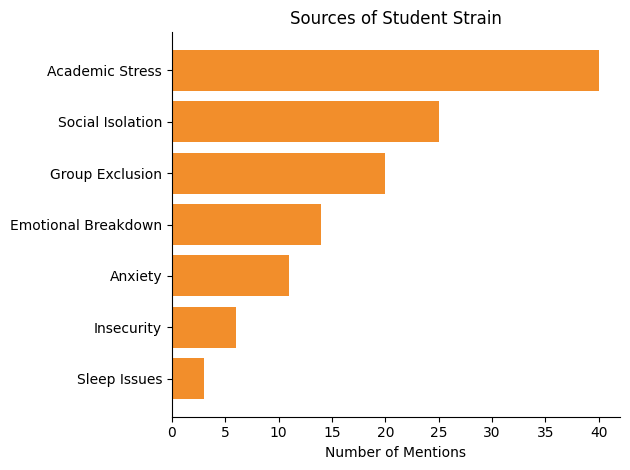

In [37]:
# Load dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("UNC_MasterDataset_WithSentiment.csv")

# Filter Cluster 2 if available
if "cluster" in df.columns:
    cluster_2 = df[df["cluster"] == 2].copy()
else:
    cluster_2 = df.copy()

text_series = cluster_2["translated_text"].astype(str).str.lower()

# --- MERGED SUBTHEMES ---
combined_subthemes = {
    "Social Isolation": 
        ["no friend", "can't find", "no circle", "alone", "dorm", "empty rooms"],
    
    "Group Exclusion": 
        ["group", "not chosen", "no one picked", "left out"],
    
    "Insecurity": 
        ["judged", "looking at me", "insecure"],
    
    "Anxiety": 
        ["anxious", "overthink", "overthinking", "panic"],
    
    "Sleep Issues": 
        ["insomnia", "can't sleep", "fell asleep at 5am"],
    
    "Emotional Breakdown": 
        ["cry", "cried", "breakdown"],
    
    "Academic Stress": 
        ["stress", "failing", "tired", "exhausted"]
}

combined_counts = {}

for theme, keywords in combined_subthemes.items():
    combined_counts[theme] = text_series.apply(
        lambda x: any(k in x for k in keywords)
    ).sum()

# Sort in decreasing order
sorted_items = sorted(combined_counts.items(), key=lambda x: x[1], reverse=True)
themes_sorted = [item[0] for item in sorted_items]
counts_sorted = [item[1] for item in sorted_items]

# Create horizontal bar chart
fig, ax = plt.subplots()

ax.barh(
    themes_sorted[::-1],   # reverse so highest appears on top
    counts_sorted[::-1],
    color="#F28E2B"
)

ax.set_title("Sources of Student Strain")
ax.set_xlabel("Number of Mentions")

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

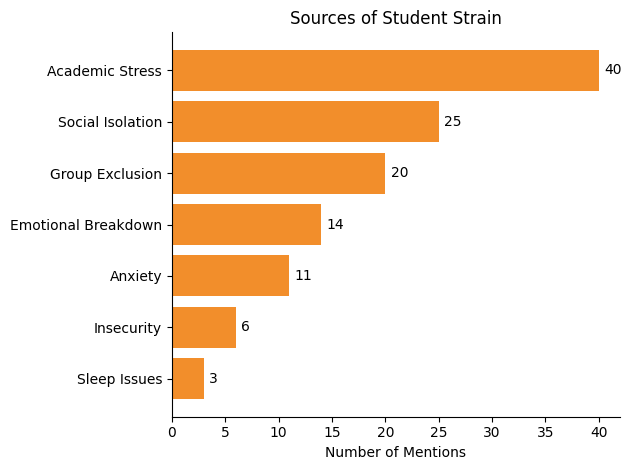

In [38]:
# Create horizontal bar chart
fig, ax = plt.subplots()

bars = ax.barh(
    themes_sorted[::-1],   # reverse so highest appears on top
    counts_sorted[::-1],
    color="#F28E2B"
)

# Add numbers beside bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5,                 # position slightly to the right
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center')

ax.set_title("Sources of Student Strain")
ax.set_xlabel("Number of Mentions")

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Student Sentiment Distribution

In [39]:
df_master["is_relevant"] = (
    df_master["is_tuition"] |
    df_master["is_protest"] |
    df_master["is_4th_year"] |
    df_master["is_pep"]
)

In [40]:
relevant_df = df_master[df_master["is_relevant"] == True].copy()

In [41]:
sentiment_dist = relevant_df["sentiment_label"].value_counts(normalize=True)
print(sentiment_dist)

sentiment_label
positive    0.638655
negative    0.336134
neutral     0.025210
Name: proportion, dtype: float64


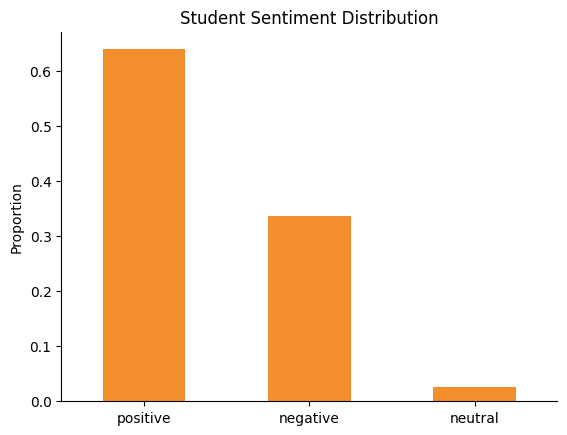

In [42]:
fig, ax = plt.subplots()

sentiment_dist.plot(
    kind="bar",
    ax=ax,
    color="#F28E2B"
)

ax.set_title("Student Sentiment Distribution")
ax.set_xlabel("")
ax.set_ylabel("Proportion")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.show()

# Tuition related posts

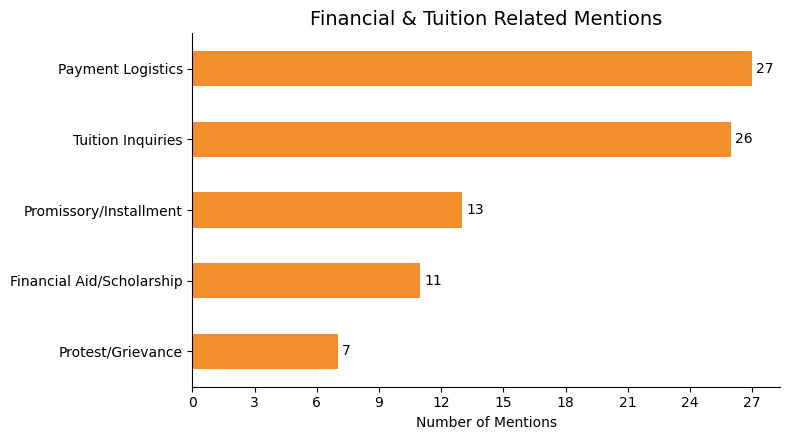

In [43]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 1. Define the specific "Financial" sub-categories
FINANCIAL_FOCUS = {
    "Payment Logistics": [
        r"\bhow to pay\b", r"\bcashier\b", r"\bonline payment\b",
        r"\boes\b", r"\bportal\b",
        r"\bpayment\b", r"\bpay\b"
    ],

    "Tuition Inquiries": [
        r"\btuition\b", r"\bfee\b", r"\bfees\b",
        r"\bmagkano\b", r"\bhow much\b"
    ],

    "Financial Aid/Scholarship": [
        r"\bscholarship\b", r"\bdiscount\b", r"\bgrant\b",
        r"\bched\b", r"\bstudent assistant\b"
    ],

    "Promissory/Installment": [
        r"\bpromissory\b", r"\binstallment\b",
        r"\bbalance\b", r"\bdownpayment\b", r"\b60%\b"
    ],

    "Protest/Grievance": [
        r"\bprotest\b", r"\brebel\b", r"\bexcessive\b",
        r"\boppose\b", r"\bhike\b", r"\braise\b"
    ]
}
def has_any(text, patterns):
    if pd.isna(text): return False
    t = str(text).lower()
    return any(re.search(p, t) for p in patterns)

# 2. Analyze the ENTIRE dataset (not just one cluster) for these terms
financial_counts = {}
for category, patterns in FINANCIAL_FOCUS.items():
    financial_counts[category] = df_master["translated_text"].apply(lambda x: has_any(x, patterns)).sum()

# 3. Create the Raymond-style chart
fin_series = pd.Series(financial_counts).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
fin_series.plot(kind="barh", ax=ax, color="#F28E2B") # Raymond's Orange

ax.set_title("Financial & Tuition Related Mentions", fontsize=14)
ax.set_xlabel("Number of Mentions")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Formatting to match Raymond
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, v in enumerate(fin_series.values):
    ax.text(v + 0.2, i, str(int(v)), va="center")

plt.tight_layout()
plt.show()